In [1]:
import numpy as np
import tikzplotlib
import math
import matplotlib.pyplot as plt
import torch
from torch.autograd.functional import jacobian
import sys
import copy
import pathlib
from pathlib import Path
cwd = Path().resolve()
import os
from os import path
# __file__ should be defined in this case
PARENT_DIR = path.dirname(cwd)
sys.path.append(PARENT_DIR)
import pickle as pkl

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/opt/anaconda3/envs/pytorch_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Metrics (NMSE, MSE) for different SMNRs 

In [2]:
import json
def load_metrics_json(file):
    with open(file, 'rb') as f:
        metrics = json.load(f)
    return metrics

In [3]:
date="2024-12-04"
ssmtype_dir="LorenzSSMn3x2"
ssmtype="LorenzSSMn2"
METRICSJSON_SemiDANSE_nsup2 = "../figs_new_{}_danse_semidanse/{}/ModTest_diff_smnr_nsup_2_Ntrain_1000_Ttrain_100_refactored/{}_test_ModTest_diff_smnr_nsup_2_Ntrain_1000_Ttrain_100_refactored_nsup_2_T_2000_N_100_ModTest.json".format(date, ssmtype_dir, ssmtype)
METRICSJSON_SemiDANSE_nsup5 = "../figs_new_{}_danse_semidanse/{}/ModTest_diff_smnr_nsup_5_Ntrain_1000_Ttrain_100_refactored/{}_test_ModTest_diff_smnr_nsup_5_Ntrain_1000_Ttrain_100_refactored_nsup_5_T_2000_N_100_ModTest.json".format(date, ssmtype_dir, ssmtype)
METRICSJSON_SemiDANSE_nsup10 = "../figs_new_{}_danse_semidanse/{}/ModTest_diff_smnr_nsup_10_Ntrain_1000_Ttrain_100_refactored/{}_test_ModTest_diff_smnr_nsup_10_Ntrain_1000_Ttrain_100_refactored_nsup_10_T_2000_N_100_ModTest.json".format(date, ssmtype_dir, ssmtype)
METRICSJSON_SemiDANSE_nsup20 = "../figs_new_{}_danse_semidanse/{}/ModTest_diff_smnr_nsup_20_Ntrain_1000_Ttrain_100_refactored/{}_test_ModTest_diff_smnr_nsup_20_Ntrain_1000_Ttrain_100_refactored_nsup_20_T_2000_N_100_ModTest.json".format(date, ssmtype_dir, ssmtype)
#METRICSJSON_SemiDANSE_nsup30 = "../figs_new_{}_danse_semidanse/{}/ModTest_diff_smnr_nsup_30_Ntrain_1000_Ttrain_100_refactored/{}_test_ModTest_diff_smnr_nsup_30_Ntrain_1000_Ttrain_100_refactored_nsup_30_T_2000_N_100_ModTest.json".format(date)
#METRICSJSON_SemiDANSE_nsup40 = "../figs_new_{}_danse_semidanse/{}/ModTest_diff_smnr_nsup_40_Ntrain_1000_Ttrain_100_refactored/{}_test_ModTest_diff_smnr_nsup_40_Ntrain_1000_Ttrain_100_refactored_nsup_40_T_2000_N_100_ModTest.json".format(date)
METRICSJSON_SemiDANSE_nsup50 = "../figs_new_{}_danse_semidanse/{}/ModTest_diff_smnr_nsup_50_Ntrain_1000_Ttrain_100_refactored/{}_test_ModTest_diff_smnr_nsup_50_Ntrain_1000_Ttrain_100_refactored_nsup_50_T_2000_N_100_ModTest.json".format(date, ssmtype_dir, ssmtype)

In [4]:
# ((nmse, nmse_std, mse, mse_std, time), (ls,danse,danse_semisupervised), smnrs)
metrics_semidanse_nsup2_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_nsup2)['result_mat']) 
metrics_semidanse_nsup5_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_nsup5)['result_mat']) 
metrics_semidanse_nsup10_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_nsup10)['result_mat']) 
metrics_semidanse_nsup20_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_nsup20)['result_mat']) 
#metrics_semidanse_nsup30_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_nsup30)['result_mat']) 
#metrics_semidanse_nsup40_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_nsup40)['result_mat']) 
metrics_semidanse_nsup50_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_nsup50)['result_mat']) 

### Creating plot NMSE vs. SMNR for PF, pDANSE ($\kappa=0\%$) 

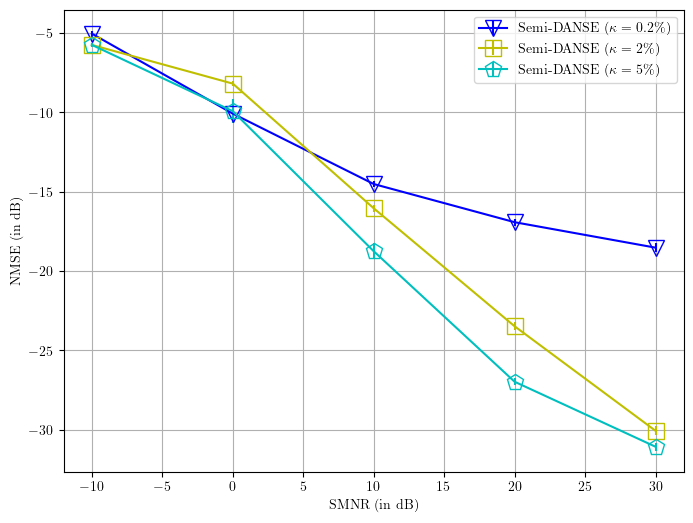

In [12]:
smnrs = np.array([-10.0, 0.0, 10.0, 20.0, 30.0])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
plt.figure(figsize=(8,6))
plt.errorbar(
    smnrs,
    metrics_semidanse_nsup2_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_nsup2_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='bv-',
    fillstyle='none',
    ms=12,
    label='Semi-DANSE $ (\kappa=0.2\%)$'
)
'''
plt.errorbar(
    smnrs,
    metrics_semidanse_nsup5_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=6)
    yerr=metrics_semidanse_nsup5_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=6),
    fmt='rv-',
    fillstyle='none',
    ms=12,
    label='Semi-DANSE $ (\kappa=0.5\%)$'
)
plt.errorbar(
    smnrs,
    metrics_semidanse_nsup10_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=10)
    yerr=metrics_semidanse_nsup10_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=10),
    fmt='gv-',
    fillstyle='none',
    ms=12,
    label='Semi-DANSE $ (\kappa=1\%)$'
)
'''
plt.errorbar(
    smnrs,
    metrics_semidanse_nsup20_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=10)
    yerr=metrics_semidanse_nsup20_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=10),
    fmt='ys-',
    fillstyle='none',
    ms=12,
    label='Semi-DANSE $ (\kappa=2\%)$'
)
plt.errorbar(
    smnrs,
    metrics_semidanse_nsup50_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=10)
    yerr=metrics_semidanse_nsup50_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=10),
    fmt='cp-',
    fillstyle='none',
    ms=12,
    label='Semi-DANSE $ (\kappa=5\%)$'
)

plt.grid(True)
plt.xlabel('SMNR (in dB)', usetex=True)
plt.ylabel('NMSE (in dB)', usetex=True)
plt.legend()
#tikzplotlib.save('../figs_new_{}_danse_semidanse/{}/nmse_vs_smnr_diff_kappa.tex'.format(date, ssmtype_dir))
plt.show()